In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files

uploaded = files.upload()

Saving matches.csv to matches.csv


In [3]:
match_df=pd.read_csv('matches.csv')


In [5]:
match_df.info()
match_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Season         214 non-null    object
 1   Tour           214 non-null    int64 
 2   Date           214 non-null    object
 3   Time           214 non-null    object
 4   Opponent       214 non-null    object
 5   HoAw           214 non-null    object
 6   ArsenalScore   214 non-null    int64 
 7   OpponentScore  214 non-null    int64 
 8   Stadium        214 non-null    object
 9   Attendance     214 non-null    int64 
 10  Coach          214 non-null    object
 11  Referee        214 non-null    object
dtypes: int64(4), object(8)
memory usage: 20.2+ KB


,Season,Tour,Date,Time,Opponent,HoAw,ArsenalScore,OpponentScore,Stadium,Attendance,Coach,Referee
0,2017/18,1,2017-08-11,20:45:00,Leicester,home,4,3,Emirates Stadium,59387,Arsène Wenger,Mike Dean
1,2017/18,2,2017-08-19,18:30:00,Stoke City,away,0,1,bet365 Stadium,29459,Arsène Wenger,Andre Marriner
2,2017/18,3,2017-08-27,17:00:00,Liverpool,away,0,4,Anfield,53206,Arsène Wenger,Craig Pawson
3,2017/18,4,2017-09-09,16:00:00,Bournemouth,home,3,0,Emirates Stadium,59262,Arsène Wenger,Anthony Taylor
4,2017/18,5,2017-09-17,14:30:00,Chelsea,away,0,0,Stamford Bridge,41478,Arsène Wenger,Michael Oliver


In [6]:
match_df.isnull().sum()

,0
Season,0
Tour,0
Date,0
Time,0
Opponent,0
HoAw,0
ArsenalScore,0
OpponentScore,0
Stadium,0
Attendance,0


In [7]:
match_df["GoalDifference"] = match_df["ArsenalScore"] - match_df["OpponentScore"]

match_df["Result"] = np.select(
    [
        match_df["ArsenalScore"] > match_df["OpponentScore"],
        match_df["ArsenalScore"] == match_df["OpponentScore"]
    ],
    ["Win", "Draw"],
    default="Loss"
)

match_df["Points"] = np.select(
    [
        match_df["Result"] == "Win",
        match_df["Result"] == "Draw"
    ],
    [3, 1],
    default=0
)

# How has Arsenal's competitive performance evolved across seasons and coaching periods from 2017–2023?

# Build the season-level performance table

In [8]:
season_performance = (
    match_df.groupby("Season")
      .agg(
          Matches=("Result", "count"),
          Wins=("Result", lambda x: (x == "Win").sum()),
          Draws=("Result", lambda x: (x == "Draw").sum()),
          Losses=("Result", lambda x: (x == "Loss").sum()),
          Goals_Scored=("ArsenalScore", "sum"),
          Goals_Conceded=("OpponentScore", "sum"),
          Points=("Points", "sum"),
          Goal_Difference=("GoalDifference", "sum")
      )
      .reset_index()
)

# Derived KPIs
season_performance["Win_%"] = (
    season_performance["Wins"] /
    season_performance["Matches"] * 100
)

season_performance["Points_Per_Match"] = (
    season_performance["Points"] /
    season_performance["Matches"]
)

season_performance["Goals_Scored_Per_Match"] = (
    season_performance["Goals_Scored"] /
    season_performance["Matches"]
)

season_performance["Goals_Conceded_Per_Match"] = (
    season_performance["Goals_Conceded"] /
    season_performance["Matches"]
)

season_performance.round(2)

,Season,Matches,Wins,Draws,Losses,Goals_Scored,Goals_Conceded,Points,Goal_Difference,Win_%,Points_Per_Match,Goals_Scored_Per_Match,Goals_Conceded_Per_Match
0,2017/18,38,19,6,13,74,51,63,23,50.00,1.66,1.95,1.34
1,2018/19,38,21,7,10,73,51,70,22,55.26,1.84,1.92,1.34
2,2019/20,38,14,14,10,56,48,56,8,36.84,1.47,1.47,1.26
3,2020/21,38,18,7,13,55,39,61,16,47.37,1.61,1.45,1.03
4,2021/22,38,22,3,13,61,48,69,13,57.89,1.82,1.61,1.26
5,2022/23,24,18,3,3,52,23,57,29,75.00,2.38,2.17,0.96


# Analyze performance by coach

In [9]:
coach_performance = (
    match_df.groupby("Coach")
      .agg(
          Matches=("Result", "count"),
          Wins=("Result", lambda x: (x == "Win").sum()),
          Draws=("Result", lambda x: (x == "Draw").sum()),
          Losses=("Result", lambda x: (x == "Loss").sum()),
          Goals_Scored=("ArsenalScore", "sum"),
          Goals_Conceded=("OpponentScore", "sum"),
          Points=("Points", "sum"),
          Goal_Difference=("GoalDifference", "sum")
      )
      .reset_index()
)

coach_performance["Win_%"] = (
    coach_performance["Wins"] /
    coach_performance["Matches"] * 100
)

coach_performance["Points_Per_Match"] = (
    coach_performance["Points"] /
    coach_performance["Matches"]
)

coach_performance["Goals_Scored_Per_Match"] = (
    coach_performance["Goals_Scored"] /
    coach_performance["Matches"]
)

coach_performance["Goals_Conceded_Per_Match"] = (
    coach_performance["Goals_Conceded"] /
    coach_performance["Matches"]
)

coach_performance.round(2)

,Coach,Matches,Wins,Draws,Losses,Goals_Scored,Goals_Conceded,Points,Goal_Difference,Win_%,Points_Per_Match,Goals_Scored_Per_Match,Goals_Conceded_Per_Match
0,Albert Stuivenberg,1,0,0,1,1,2,0,-1,0.00,0.00,1.00,2.00
1,Arsène Wenger,38,19,6,13,74,51,63,23,50.00,1.66,1.95,1.34
2,Freddie Ljungberg,5,1,2,2,6,8,5,-2,20.00,1.00,1.20,1.60
3,Mikel Arteta,119,67,19,33,199,129,220,70,56.30,1.85,1.67,1.08
4,Unai Emery,51,25,13,13,91,70,88,21,49.02,1.73,1.78,1.37


# Visualize the performance trend

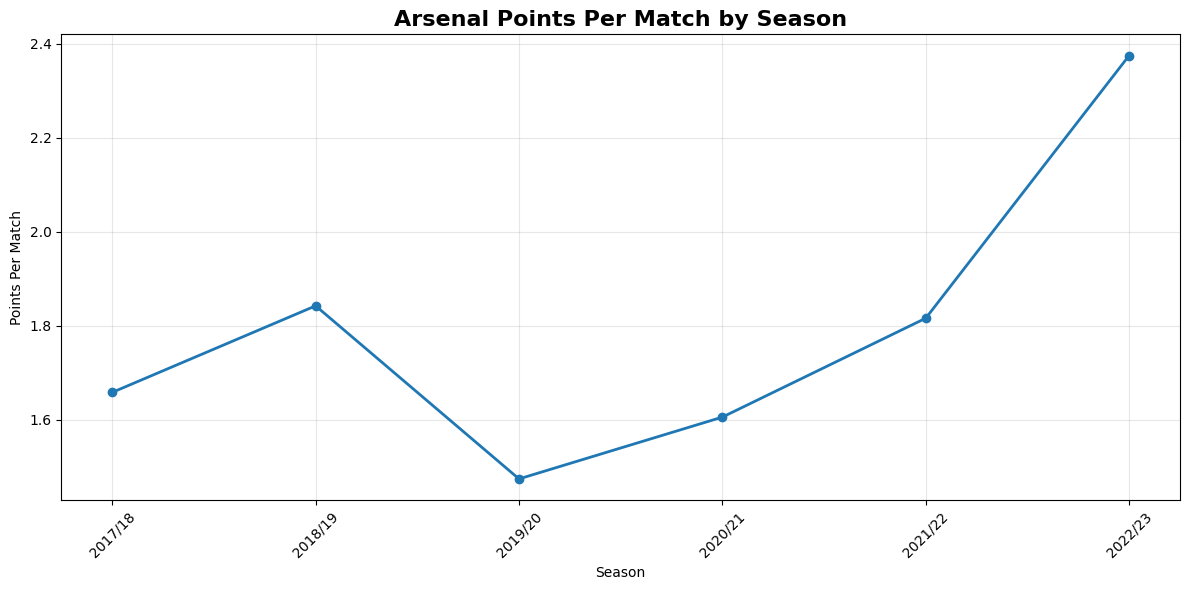

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    season_performance["Season"],
    season_performance["Points_Per_Match"],
    marker="o",
    linewidth=2
)

plt.title(
    "Arsenal Points Per Match by Season",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Points Per Match")
plt.xticks(rotation=45)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

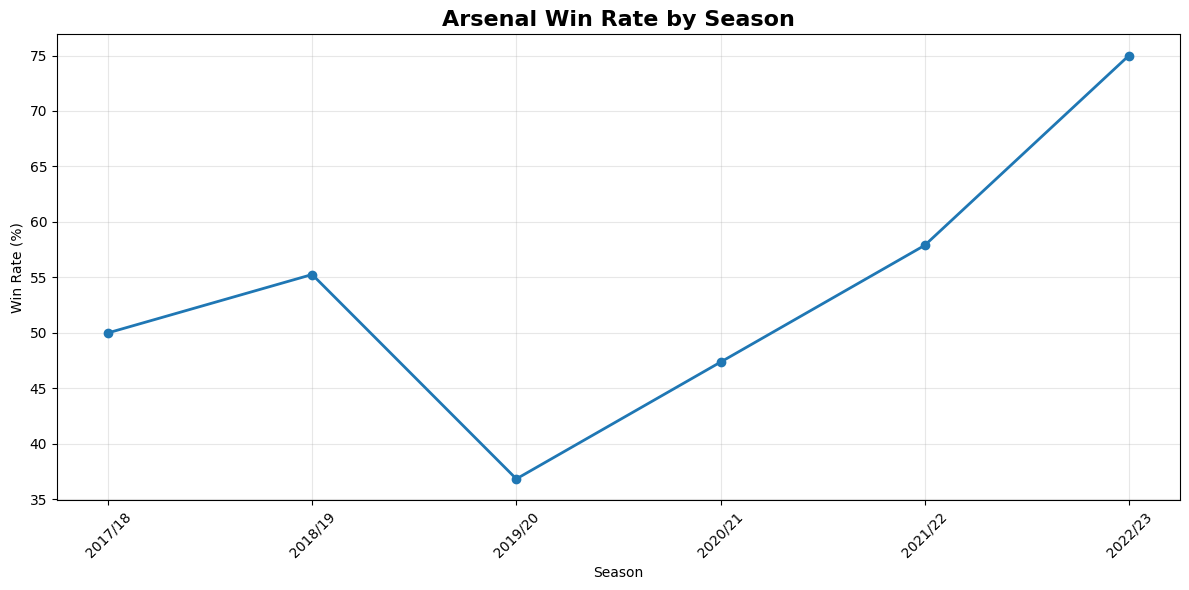

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(
    season_performance["Season"],
    season_performance["Win_%"],
    marker="o",
    linewidth=2
)

plt.title(
    "Arsenal Win Rate by Season",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=45)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

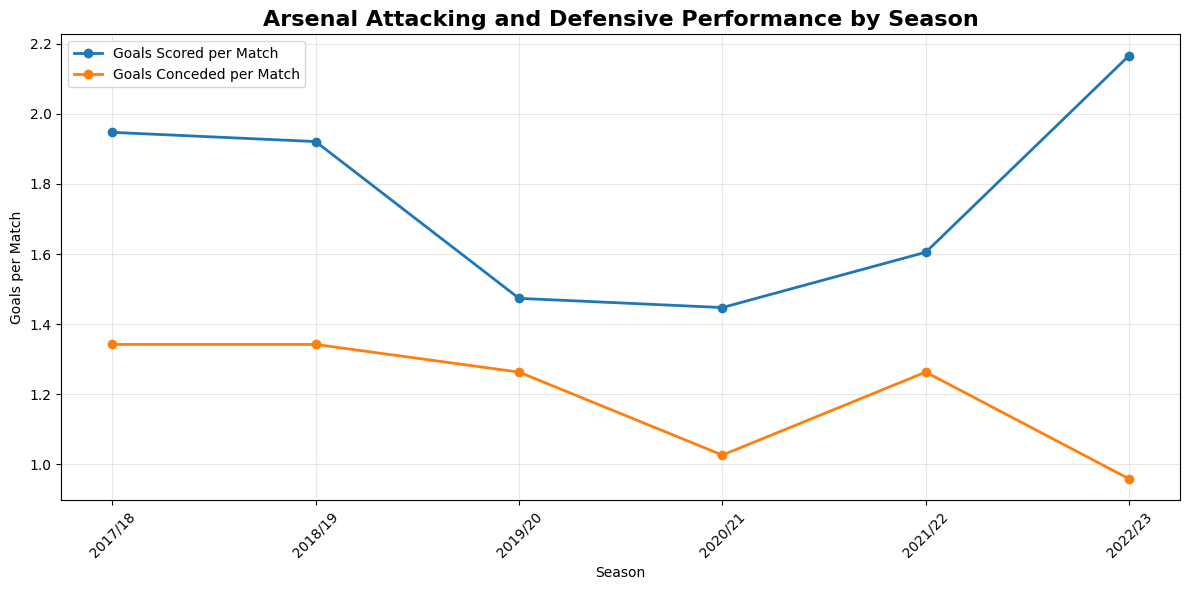

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    season_performance["Season"],
    season_performance["Goals_Scored_Per_Match"],
    marker="o",
    linewidth=2,
    label="Goals Scored per Match"
)

plt.plot(
    season_performance["Season"],
    season_performance["Goals_Conceded_Per_Match"],
    marker="o",
    linewidth=2,
    label="Goals Conceded per Match"
)

plt.title(
    "Arsenal Attacking and Defensive Performance by Season",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Goals per Match")
plt.xticks(rotation=45)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Which opponents represent Arsenal's biggest competitive weaknesses between 2017 and 2023?

# Create an opponent performance table

In [13]:
opponent_performance = (
    match_df.groupby("Opponent")
      .agg(
          Matches=("Result", "count"),
          Wins=("Result", lambda x: (x == "Win").sum()),
          Draws=("Result", lambda x: (x == "Draw").sum()),
          Losses=("Result", lambda x: (x == "Loss").sum()),
          Goals_Scored=("ArsenalScore", "sum"),
          Goals_Conceded=("OpponentScore", "sum"),
          Points=("Points", "sum"),
          Goal_Difference=("GoalDifference", "sum")
      )
      .reset_index()
)

# Derived metrics
opponent_performance["Win_%"] = (
    opponent_performance["Wins"] /
    opponent_performance["Matches"] * 100
)

opponent_performance["Points_Per_Match"] = (
    opponent_performance["Points"] /
    opponent_performance["Matches"]
)

opponent_performance["Goals_Scored_Per_Match"] = (
    opponent_performance["Goals_Scored"] /
    opponent_performance["Matches"]
)

opponent_performance["Goals_Conceded_Per_Match"] = (
    opponent_performance["Goals_Conceded"] /
    opponent_performance["Matches"]
)

opponent_performance = opponent_performance.round(2)

opponent_performance

,Opponent,Matches,Wins,Draws,Losses,Goals_Scored,Goals_Conceded,Points,Goal_Difference,Win_%,Points_Per_Match,Goals_Scored_Per_Match,Goals_Conceded_Per_Match
0,Aston Villa,8,5,0,3,13,11,15,2,62.50,1.88,1.62,1.38
1,Bournemouth,7,5,1,1,16,5,16,11,71.43,2.29,2.29,0.71
2,Brentford,4,2,1,1,6,4,7,2,50.00,1.75,1.50,1.00
3,Brighton,11,4,3,4,15,12,15,3,36.36,1.36,1.36,1.09
4,Burnley,10,6,3,1,16,5,21,11,60.00,2.10,1.60,0.50
5,Cardiff,2,2,0,0,5,3,6,2,100.00,3.00,2.50,1.50
6,Chelsea,11,5,3,3,18,14,18,4,45.45,1.64,1.64,1.27
7,Crystal Palace,11,4,5,2,21,17,17,4,36.36,1.55,1.91,1.55
8,Everton,11,5,1,5,22,13,16,9,45.45,1.45,2.00,1.18
9,Fulham,5,4,1,0,15,4,13,11,80.00,2.60,3.00,0.80


In [14]:
opponent_performance.sort_values(
    "Matches",
    ascending=False
)

,Opponent,Matches,Wins,Draws,Losses,Goals_Scored,Goals_Conceded,Points,Goal_Difference,Win_%,Points_Per_Match,Goals_Scored_Per_Match,Goals_Conceded_Per_Match
15,Man Utd,12,5,3,4,19,17,18,2,41.67,1.50,1.58,1.42
23,Tottenham,12,6,2,4,20,16,20,4,50.00,1.67,1.67,1.33
12,Leicester,12,7,1,4,21,17,22,4,58.33,1.83,1.75,1.42
3,Brighton,11,4,3,4,15,12,15,3,36.36,1.36,1.36,1.09
14,Man City,11,0,0,11,4,29,0,-25,0.00,0.00,0.36,2.64
20,Southampton,11,5,4,2,20,12,19,8,45.45,1.73,1.82,1.09
26,West Ham,11,8,2,1,23,10,26,13,72.73,2.36,2.09,0.91
16,Newcastle,11,8,1,2,18,5,25,13,72.73,2.27,1.64,0.45
13,Liverpool,11,2,2,7,12,31,8,-19,18.18,0.73,1.09,2.82
8,Everton,11,5,1,5,22,13,16,9,45.45,1.45,2.00,1.18


# Identify Arsenal's difficult opponents

In [15]:
difficult_opponents = (
    opponent_performance[
        opponent_performance["Matches"] >= 3
    ]
    .sort_values(
        ["Points_Per_Match", "Win_%"],
        ascending=[True, True]
    )
)

difficult_opponents

,Opponent,Matches,Wins,Draws,Losses,Goals_Scored,Goals_Conceded,Points,Goal_Difference,Win_%,Points_Per_Match,Goals_Scored_Per_Match,Goals_Conceded_Per_Match
14,Man City,11,0,0,11,4,29,0,-25,0.00,0.00,0.36,2.64
13,Liverpool,11,2,2,7,12,31,8,-19,18.18,0.73,1.09,2.82
3,Brighton,11,4,3,4,15,12,15,3,36.36,1.36,1.36,1.09
8,Everton,11,5,1,5,22,13,16,9,45.45,1.45,2.00,1.18
15,Man Utd,12,5,3,4,19,17,18,2,41.67,1.50,1.58,1.42
7,Crystal Palace,11,4,5,2,21,17,17,4,36.36,1.55,1.91,1.55
27,Wolves,9,4,2,3,12,10,14,2,44.44,1.56,1.33,1.11
6,Chelsea,11,5,3,3,18,14,18,4,45.45,1.64,1.64,1.27
23,Tottenham,12,6,2,4,20,16,20,4,50.00,1.67,1.67,1.33
20,Southampton,11,5,4,2,20,12,19,8,45.45,1.73,1.82,1.09


# Look at the worst opponents

In [16]:
difficult_opponents[
    [
        "Opponent",
        "Matches",
        "Wins",
        "Draws",
        "Losses",
        "Win_%",
        "Points_Per_Match",
        "Goals_Scored_Per_Match",
        "Goals_Conceded_Per_Match",
        "Goal_Difference"
    ]
]

,Opponent,Matches,Wins,Draws,Losses,Win_%,Points_Per_Match,Goals_Scored_Per_Match,Goals_Conceded_Per_Match,Goal_Difference
14,Man City,11,0,0,11,0.00,0.00,0.36,2.64,-25
13,Liverpool,11,2,2,7,18.18,0.73,1.09,2.82,-19
3,Brighton,11,4,3,4,36.36,1.36,1.36,1.09,3
8,Everton,11,5,1,5,45.45,1.45,2.00,1.18,9
15,Man Utd,12,5,3,4,41.67,1.50,1.58,1.42,2
7,Crystal Palace,11,4,5,2,36.36,1.55,1.91,1.55,4
27,Wolves,9,4,2,3,44.44,1.56,1.33,1.11,2
6,Chelsea,11,5,3,3,45.45,1.64,1.64,1.27,4
23,Tottenham,12,6,2,4,50.00,1.67,1.67,1.33,4
20,Southampton,11,5,4,2,45.45,1.73,1.82,1.09,8


# Identify Arsenal's strongest opponents

In [17]:
strong_opponents = (
    opponent_performance[
        opponent_performance["Matches"] >= 3
    ]
    .sort_values(
        ["Points_Per_Match", "Win_%"],
        ascending=[False, False]
    )
)

strong_opponents

,Opponent,Matches,Wins,Draws,Losses,Goals_Scored,Goals_Conceded,Points,Goal_Difference,Win_%,Points_Per_Match,Goals_Scored_Per_Match,Goals_Conceded_Per_Match
10,Huddersfield,4,4,0,0,9,1,12,8,100.00,3.00,2.25,0.25
9,Fulham,5,4,1,0,15,4,13,11,80.00,2.60,3.00,0.80
11,Leeds,5,4,1,0,11,4,13,7,80.00,2.60,2.20,0.80
17,Norwich,4,3,1,0,12,2,10,10,75.00,2.50,3.00,0.50
25,West Brom,4,3,1,0,10,2,10,8,75.00,2.50,2.50,0.50
24,Watford,8,6,1,1,16,8,19,8,75.00,2.38,2.00,1.00
26,West Ham,11,8,2,1,23,10,26,13,72.73,2.36,2.09,0.91
1,Bournemouth,7,5,1,1,16,5,16,11,71.43,2.29,2.29,0.71
16,Newcastle,11,8,1,2,18,5,25,13,72.73,2.27,1.64,0.45
4,Burnley,10,6,3,1,16,5,21,11,60.00,2.10,1.60,0.50


In [19]:
match_df["HoAw"].value_counts()

,count
HoAw,
away,108
home,106


In [20]:
match_df["HoAw"].unique()

array(['home', 'away'], dtype=object)

# Does Arsenal have a significant home advantage, and how has home vs away performance changed from 2017–2023?

# Build the Home vs Away performance table

In [21]:
home_away_performance = (
    match_df.groupby("HoAw")
      .agg(
          Matches=("Result", "count"),
          Wins=("Result", lambda x: (x == "Win").sum()),
          Draws=("Result", lambda x: (x == "Draw").sum()),
          Losses=("Result", lambda x: (x == "Loss").sum()),
          Goals_Scored=("ArsenalScore", "sum"),
          Goals_Conceded=("OpponentScore", "sum"),
          Points=("Points", "sum"),
          Goal_Difference=("GoalDifference", "sum")
      )
      .reset_index()
)

# Derived metrics
home_away_performance["Win_%"] = (
    home_away_performance["Wins"] /
    home_away_performance["Matches"] * 100
)

home_away_performance["Points_Per_Match"] = (
    home_away_performance["Points"] /
    home_away_performance["Matches"]
)

home_away_performance["Goals_Scored_Per_Match"] = (
    home_away_performance["Goals_Scored"] /
    home_away_performance["Matches"]
)

home_away_performance["Goals_Conceded_Per_Match"] = (
    home_away_performance["Goals_Conceded"] /
    home_away_performance["Matches"]
)

home_away_performance["Goal_Difference_Per_Match"] = (
    home_away_performance["Goal_Difference"] /
    home_away_performance["Matches"]
)

home_away_performance.round(2)

,HoAw,Matches,Wins,Draws,Losses,Goals_Scored,Goals_Conceded,Points,Goal_Difference,Win_%,Points_Per_Match,Goals_Scored_Per_Match,Goals_Conceded_Per_Match,Goal_Difference_Per_Match
0,away,108,44,21,43,153,148,153,5,40.74,1.42,1.42,1.37,0.05
1,home,106,68,19,19,218,112,223,106,64.15,2.10,2.06,1.06,1.00


# Calculate the home advantage

In [22]:
home = home_away_performance[
    home_away_performance["HoAw"] == "home"
].iloc[0]

away = home_away_performance[
    home_away_performance["HoAw"] == "away"
].iloc[0]

print("Home win advantage:", round(home["Win_%"] - away["Win_%"], 2), "percentage points")
print("PPM advantage:", round(home["Points_Per_Match"] - away["Points_Per_Match"], 2))
print("Goal difference advantage:", round(
    home["Goal_Difference_Per_Match"] -
    away["Goal_Difference_Per_Match"], 2
))

Home win advantage: 23.41 percentage points
PPM advantage: 0.69
Goal difference advantage: 0.95


# Then we'll investigate the trend

In [23]:
season_home_away = (
    match_df.groupby(["Season", "HoAw"])
      .agg(
          Matches=("Result", "count"),
          Wins=("Result", lambda x: (x == "Win").sum()),
          Draws=("Result", lambda x: (x == "Draw").sum()),
          Losses=("Result", lambda x: (x == "Loss").sum()),
          Goals_Scored=("ArsenalScore", "sum"),
          Goals_Conceded=("OpponentScore", "sum"),
          Points=("Points", "sum")
      )
      .reset_index()
)

season_home_away["Win_%"] = (
    season_home_away["Wins"] /
    season_home_away["Matches"] * 100
)

season_home_away["Points_Per_Match"] = (
    season_home_away["Points"] /
    season_home_away["Matches"]
)

season_home_away["Goals_Scored_Per_Match"] = (
    season_home_away["Goals_Scored"] /
    season_home_away["Matches"]
)

season_home_away["Goals_Conceded_Per_Match"] = (
    season_home_away["Goals_Conceded"] /
    season_home_away["Matches"]
)

season_home_away.round(2)

,Season,HoAw,Matches,Wins,Draws,Losses,Goals_Scored,Goals_Conceded,Points,Win_%,Points_Per_Match,Goals_Scored_Per_Match,Goals_Conceded_Per_Match
0,2017/18,away,19,4,4,11,20,31,16,21.05,0.84,1.05,1.63
1,2017/18,home,19,15,2,2,54,20,47,78.95,2.47,2.84,1.05
2,2018/19,away,19,7,4,8,31,35,25,36.84,1.32,1.63,1.84
3,2018/19,home,19,14,3,2,42,16,45,73.68,2.37,2.21,0.84
4,2019/20,away,19,4,8,7,20,24,20,21.05,1.05,1.05,1.26
5,2019/20,home,19,10,6,3,36,24,36,52.63,1.89,1.89,1.26
6,2020/21,away,19,10,3,6,31,18,33,52.63,1.74,1.63,0.95
7,2020/21,home,19,8,4,7,24,21,28,42.11,1.47,1.26,1.11
8,2021/22,away,19,9,1,9,26,31,28,47.37,1.47,1.37,1.63
9,2021/22,home,19,13,2,4,35,17,41,68.42,2.16,1.84,0.89


# Which Arsenal players were the most influential in the team's performance between 2017 and 2023?

In [25]:
from google.colab import files

uploaded = files.upload()

Saving players.csv to players.csv


In [26]:
players_df = pd.read_csv("players.csv")


In [27]:
players_df.info()
players_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2741 entries, 0 to 2740
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LastName   2741 non-null   object 
 1   FirstName  2741 non-null   object 
 2   Date       2741 non-null   object 
 3   Start      2741 non-null   int64  
 4   Pos        2741 non-null   object 
 5   Min        2741 non-null   int64  
 6   G          2741 non-null   int64  
 7   A          2741 non-null   int64  
 8   PK         2741 non-null   int64  
 9   PKA        2741 non-null   int64  
 10  S          2741 non-null   int64  
 11  SoT        2741 non-null   int64  
 12  YK         2741 non-null   int64  
 13  RK         2741 non-null   int64  
 14  Touches    2741 non-null   int64  
 15  Tackles    2741 non-null   int64  
 16  Ints       2741 non-null   int64  
 17  Blocks     2741 non-null   int64  
 18  xG         2741 non-null   float64
 19  npxG       2741 non-null   float64
 20  xAG     

,LastName,FirstName,Date,Start,Pos,Min,G,A,PK,PKA,...,xG,npxG,xAG,Passes,PassesA,PrgPas,Carries,PrgCar,Line,C
0,Bellerin,Hector,8/11/2017,1,WB,90,0,0,0,0,...,0.3,0.3,0.0,61,70,3,51,1,Defender,0
1,Elneny,Mohamed,8/11/2017,1,CM,66,0,1,0,0,...,0.0,0.0,0.1,65,72,4,57,0,Midfielder,0
2,Holding,Rob,8/11/2017,1,CB,66,0,0,0,0,...,0.0,0.0,0.0,50,60,4,50,1,Defender,0
3,Kolasinac,Sead,8/11/2017,1,CB,90,0,1,0,0,...,0.0,0.0,0.6,59,73,9,49,7,Defender,0
4,Lacazette,Alexandre,8/11/2017,1,FW,90,1,0,0,0,...,0.3,0.3,0.4,20,24,3,19,1,Forward,0


# Create the player's full name

In [28]:
players_df["Player"] = (
    players_df["FirstName"].str.strip()
    + " "
    + players_df["LastName"].str.strip()
)

In [29]:
players_df["Player"].head(10)

,Player
0,Hector Bellerin
1,Mohamed Elneny
2,Rob Holding
3,Sead Kolasinac
4,Alexandre Lacazette
5,Nacho Monreal
6,Mesut Ozil
7,Danny Welbeck
8,Granit Xhaka
9,Aaron Ramsey


# Aggregate player performance

In [30]:
player_performance = (
    players_df.groupby("Player")
    .agg(
        Matches=("Date", "count"),
        Starts=("Start", "sum"),
        Minutes=("Min", "sum"),
        Goals=("G", "sum"),
        Assists=("A", "sum"),
        xG=("xG", "sum"),
        xAG=("xAG", "sum"),
        Shots=("S", "sum"),
        Shots_on_Target=("SoT", "sum"),
        Touches=("Touches", "sum"),
        Tackles=("Tackles", "sum"),
        Interceptions=("Ints", "sum"),
        Blocks=("Blocks", "sum"),
        Progressive_Passes=("PrgPas", "sum"),
        Progressive_Carries=("PrgCar", "sum"),
        Passes=("Passes", "sum"),
        Carries=("Carries", "sum")
    )
    .reset_index()
)

# Create per-90 metrics

In [31]:
player_performance["Goals_Per_90"] = (
    player_performance["Goals"] /
    player_performance["Minutes"] * 90
)

player_performance["Assists_Per_90"] = (
    player_performance["Assists"] /
    player_performance["Minutes"] * 90
)

player_performance["xG_Per_90"] = (
    player_performance["xG"] /
    player_performance["Minutes"] * 90
)

player_performance["xAG_Per_90"] = (
    player_performance["xAG"] /
    player_performance["Minutes"] * 90
)

player_performance["Progressive_Passes_Per_90"] = (
    player_performance["Progressive_Passes"] /
    player_performance["Minutes"] * 90
)

player_performance["Progressive_Carries_Per_90"] = (
    player_performance["Progressive_Carries"] /
    player_performance["Minutes"] * 90
)

player_performance["Tackles_Per_90"] = (
    player_performance["Tackles"] /
    player_performance["Minutes"] * 90
)

player_performance["Interceptions_Per_90"] = (
    player_performance["Interceptions"] /
    player_performance["Minutes"] * 90
)

In [32]:
established_players = player_performance[
    player_performance["Minutes"] >= 900
].copy()

In [33]:
established_players.sort_values(
    "Goals",
    ascending=False
).head(15)

,Player,Matches,Starts,Minutes,Goals,Assists,xG,xAG,Shots,Shots_on_Target,...,Passes,Carries,Goals_Per_90,Assists_Per_90,xG_Per_90,xAG_Per_90,Progressive_Passes_Per_90,Progressive_Carries_Per_90,Tackles_Per_90,Interceptions_Per_90
46,Pierre-Emerick Aubameyang,128,115,10288,68,16,61.7,12.0,297,126,...,1999,2269,0.594868,0.139969,0.539755,0.104977,2.204510,2.598173,0.699844,0.279938
4,Alexandre Lacazette,158,117,10283,54,25,54.0,16.5,284,123,...,2278,2412,0.472625,0.218808,0.472625,0.144413,2.686959,1.216571,1.181562,0.402606
7,Bukayo Saka,121,109,9363,26,23,26.2,20.9,226,70,...,3082,3306,0.249920,0.221083,0.251842,0.200897,3.200897,3.873758,1.278436,0.692086
24,Gabriel Martinelli,81,57,5026,20,9,19.1,11.4,138,48,...,1218,1584,0.358138,0.161162,0.342021,0.204138,2.345802,4.011142,1.289296,0.680462
41,Nicolas Pepe,80,43,4322,16,9,13.3,7.6,119,43,...,1412,1615,0.333179,0.187413,0.276955,0.158260,2.686256,3.623323,1.249422,0.583063
36,Martin Odegaard,73,64,5597,16,12,11.7,14.7,125,40,...,2674,2241,0.257281,0.192961,0.188137,0.236377,7.332500,2.106486,1.254243,0.257281
15,Eddie Nketiah,78,28,2940,14,2,16.4,3.8,98,37,...,560,705,0.428571,0.061224,0.502041,0.116327,1.806122,2.602041,0.979592,0.214286
16,Emile Smith Rowe,60,40,3510,12,6,7.9,5.6,55,28,...,1379,1230,0.307692,0.153846,0.202564,0.143590,4.025641,3.076923,0.769231,0.666667
25,Granit Xhaka,180,176,15229,11,20,9.0,15.2,180,48,...,10781,8405,0.065008,0.118196,0.053188,0.089829,9.278351,1.477444,1.637008,0.880557
0,Aaron Ramsey,52,35,3177,11,14,9.5,7.0,89,38,...,1717,1656,0.311615,0.396601,0.269122,0.198300,6.288952,3.059490,1.954674,0.934844


In [34]:
established_players.sort_values(
    "Goals_Per_90",
    ascending=False
).head(15)

,Player,Matches,Starts,Minutes,Goals,Assists,xG,xAG,Shots,Shots_on_Target,...,Passes,Carries,Goals_Per_90,Assists_Per_90,xG_Per_90,xAG_Per_90,Progressive_Passes_Per_90,Progressive_Carries_Per_90,Tackles_Per_90,Interceptions_Per_90
46,Pierre-Emerick Aubameyang,128,115,10288,68,16,61.7,12.0,297,126,...,1999,2269,0.594868,0.139969,0.539755,0.104977,2.204510,2.598173,0.699844,0.279938
4,Alexandre Lacazette,158,117,10283,54,25,54.0,16.5,284,123,...,2278,2412,0.472625,0.218808,0.472625,0.144413,2.686959,1.216571,1.181562,0.402606
15,Eddie Nketiah,78,28,2940,14,2,16.4,3.8,98,37,...,560,705,0.428571,0.061224,0.502041,0.116327,1.806122,2.602041,0.979592,0.214286
5,Alexis Sanchez,19,17,1503,7,3,8.0,5.2,68,24,...,643,866,0.419162,0.179641,0.479042,0.311377,8.922156,2.994012,1.197605,0.359281
12,Danny Welbeck,36,13,1347,6,3,6.3,1.7,36,15,...,355,427,0.400891,0.200445,0.420935,0.113586,2.204900,2.405345,1.536748,0.801782
20,Gabriel Jesus,14,14,1219,5,5,7.8,2.6,50,20,...,325,370,0.369155,0.369155,0.575882,0.191961,2.805578,2.214930,1.402789,0.590648
24,Gabriel Martinelli,81,57,5026,20,9,19.1,11.4,138,48,...,1218,1584,0.358138,0.161162,0.342021,0.204138,2.345802,4.011142,1.289296,0.680462
41,Nicolas Pepe,80,43,4322,16,9,13.3,7.6,119,43,...,1412,1615,0.333179,0.187413,0.276955,0.158260,2.686256,3.623323,1.249422,0.583063
0,Aaron Ramsey,52,35,3177,11,14,9.5,7.0,89,38,...,1717,1656,0.311615,0.396601,0.269122,0.198300,6.288952,3.059490,1.954674,0.934844
16,Emile Smith Rowe,60,40,3510,12,6,7.9,5.6,55,28,...,1379,1230,0.307692,0.153846,0.202564,0.143590,4.025641,3.076923,0.769231,0.666667


In [35]:
established_players.sort_values(
    "Goals",
    ascending=False
).head(15)

,Player,Matches,Starts,Minutes,Goals,Assists,xG,xAG,Shots,Shots_on_Target,...,Passes,Carries,Goals_Per_90,Assists_Per_90,xG_Per_90,xAG_Per_90,Progressive_Passes_Per_90,Progressive_Carries_Per_90,Tackles_Per_90,Interceptions_Per_90
46,Pierre-Emerick Aubameyang,128,115,10288,68,16,61.7,12.0,297,126,...,1999,2269,0.594868,0.139969,0.539755,0.104977,2.204510,2.598173,0.699844,0.279938
4,Alexandre Lacazette,158,117,10283,54,25,54.0,16.5,284,123,...,2278,2412,0.472625,0.218808,0.472625,0.144413,2.686959,1.216571,1.181562,0.402606
7,Bukayo Saka,121,109,9363,26,23,26.2,20.9,226,70,...,3082,3306,0.249920,0.221083,0.251842,0.200897,3.200897,3.873758,1.278436,0.692086
24,Gabriel Martinelli,81,57,5026,20,9,19.1,11.4,138,48,...,1218,1584,0.358138,0.161162,0.342021,0.204138,2.345802,4.011142,1.289296,0.680462
41,Nicolas Pepe,80,43,4322,16,9,13.3,7.6,119,43,...,1412,1615,0.333179,0.187413,0.276955,0.158260,2.686256,3.623323,1.249422,0.583063
36,Martin Odegaard,73,64,5597,16,12,11.7,14.7,125,40,...,2674,2241,0.257281,0.192961,0.188137,0.236377,7.332500,2.106486,1.254243,0.257281
15,Eddie Nketiah,78,28,2940,14,2,16.4,3.8,98,37,...,560,705,0.428571,0.061224,0.502041,0.116327,1.806122,2.602041,0.979592,0.214286
16,Emile Smith Rowe,60,40,3510,12,6,7.9,5.6,55,28,...,1379,1230,0.307692,0.153846,0.202564,0.143590,4.025641,3.076923,0.769231,0.666667
25,Granit Xhaka,180,176,15229,11,20,9.0,15.2,180,48,...,10781,8405,0.065008,0.118196,0.053188,0.089829,9.278351,1.477444,1.637008,0.880557
0,Aaron Ramsey,52,35,3177,11,14,9.5,7.0,89,38,...,1717,1656,0.311615,0.396601,0.269122,0.198300,6.288952,3.059490,1.954674,0.934844


In [36]:
established_players.sort_values(
    "Minutes",
    ascending=False
).head(15)

,Player,Matches,Starts,Minutes,Goals,Assists,xG,xAG,Shots,Shots_on_Target,...,Passes,Carries,Goals_Per_90,Assists_Per_90,xG_Per_90,xAG_Per_90,Progressive_Passes_Per_90,Progressive_Carries_Per_90,Tackles_Per_90,Interceptions_Per_90
25,Granit Xhaka,180,176,15229,11,20,9.0,15.2,180,48,...,10781,8405,0.065008,0.118196,0.053188,0.089829,9.278351,1.477444,1.637008,0.880557
46,Pierre-Emerick Aubameyang,128,115,10288,68,16,61.7,12.0,297,126,...,1999,2269,0.594868,0.139969,0.539755,0.104977,2.204510,2.598173,0.699844,0.279938
4,Alexandre Lacazette,158,117,10283,54,25,54.0,16.5,284,123,...,2278,2412,0.472625,0.218808,0.472625,0.144413,2.686959,1.216571,1.181562,0.402606
7,Bukayo Saka,121,109,9363,26,23,26.2,20.9,226,70,...,3082,3306,0.249920,0.221083,0.251842,0.200897,3.200897,3.873758,1.278436,0.692086
26,Hector Bellerin,94,89,7831,4,10,3.8,8.9,69,19,...,4282,3269,0.045971,0.114928,0.043673,0.102286,4.459201,2.436470,1.390627,1.091815
22,Gabriel Magalhaes,82,81,7219,9,0,7.6,0.8,66,22,...,4494,3849,0.112204,0.000000,0.094750,0.009974,3.590525,0.511151,1.346447,0.723092
50,Shkodran Mustafi,76,69,6138,5,2,3.0,2.2,42,16,...,3702,3043,0.073314,0.029326,0.043988,0.032258,4.076246,0.659824,2.111437,1.950147
49,Sead Kolasinac,80,68,5916,2,11,2.8,10.6,34,8,...,3101,2267,0.030426,0.167343,0.042596,0.161258,3.909736,2.738337,1.703854,1.156187
30,Kieran Tierney,80,64,5673,3,7,1.2,6.3,41,12,...,2679,2255,0.047594,0.111052,0.019038,0.099947,4.108937,2.934955,1.189847,0.777366
48,Rob Holding,82,61,5633,1,1,1.8,0.4,23,3,...,3367,2878,0.015977,0.015977,0.028759,0.006391,3.674774,0.431386,1.453932,1.150364


In [37]:
players_df["Date"] = pd.to_datetime(players_df["Date"])

print(players_df["Date"].min())
print(players_df["Date"].max())

2017-08-11 00:00:00
2023-02-25 00:00:00


In [38]:
players_df["Date"].dt.year.value_counts().sort_index()

,count
Date,
2017,238
2018,458
2019,489
2020,453
2021,533
2022,465
2023,105


In [39]:
players_df["Pos"].value_counts()

,count
Pos,
CB,525
FW,335
DM,267
AM,239
LW,225
RW,224
CM,223
LB,205
RB,203


In [40]:
player_position = (
    players_df.groupby(["Player", "Pos"])
    .agg(
        Matches=("Date", "count"),
        Starts=("Start", "sum"),
        Minutes=("Min", "sum"),
        Goals=("G", "sum"),
        Assists=("A", "sum"),
        xG=("xG", "sum"),
        xAG=("xAG", "sum"),
        Shots=("S", "sum"),
        Shots_on_Target=("SoT", "sum"),
        Tackles=("Tackles", "sum"),
        Interceptions=("Ints", "sum"),
        Blocks=("Blocks", "sum"),
        Progressive_Passes=("PrgPas", "sum"),
        Progressive_Carries=("PrgCar", "sum")
    )
    .reset_index()
)

In [41]:
player_position["Goals_Per_90"] = (
    player_position["Goals"] /
    player_position["Minutes"] * 90
)

player_position["Assists_Per_90"] = (
    player_position["Assists"] /
    player_position["Minutes"] * 90
)

player_position["xG_Per_90"] = (
    player_position["xG"] /
    player_position["Minutes"] * 90
)

player_position["xAG_Per_90"] = (
    player_position["xAG"] /
    player_position["Minutes"] * 90
)

player_position["Tackles_Per_90"] = (
    player_position["Tackles"] /
    player_position["Minutes"] * 90
)

player_position["Interceptions_Per_90"] = (
    player_position["Interceptions"] /
    player_position["Minutes"] * 90
)

player_position["Blocks_Per_90"] = (
    player_position["Blocks"] /
    player_position["Minutes"] * 90
)

player_position["Progressive_Passes_Per_90"] = (
    player_position["Progressive_Passes"] /
    player_position["Minutes"] * 90
)

player_position["Progressive_Carries_Per_90"] = (
    player_position["Progressive_Carries"] /
    player_position["Minutes"] * 90
)

In [42]:
player_position_900 = player_position[
    player_position["Minutes"] >= 900
].copy()

In [43]:
player_position_900.groupby("Pos")["Player"].nunique().sort_values(
    ascending=False
)

,Player
Pos,
CB,11
CM,7
AM,6
DM,6
LB,6
RB,6
LW,4
FW,4
RW,3


In [44]:
attackers = player_position_900[
    player_position_900["Pos"].isin(["FW", "LW", "RW"])
].copy()

attackers.sort_values(
    "Goals_Per_90",
    ascending=False
)[[
    "Player",
    "Pos",
    "Minutes",
    "Goals",
    "Assists",
    "Goals_Per_90",
    "Assists_Per_90",
    "xG_Per_90",
    "xAG_Per_90"
]].head(15)

,Player,Pos,Minutes,Goals,Assists,Goals_Per_90,Assists_Per_90,xG_Per_90,xAG_Per_90
176,Pierre-Emerick Aubameyang,LW,3418,25,6,0.658280,0.157987,0.426565,0.105325
175,Pierre-Emerick Aubameyang,FW,6015,37,9,0.553616,0.134663,0.602993,0.098753
30,Alexandre Lacazette,FW,9972,54,25,0.487365,0.225632,0.480144,0.145307
67,Eddie Nketiah,FW,2664,13,2,0.439189,0.067568,0.506757,0.111486
42,Bukayo Saka,RW,5314,24,15,0.406473,0.254046,0.318404,0.238803
91,Gabriel Martinelli,LW,4138,17,7,0.369744,0.152247,0.343644,0.210971
83,Gabriel Jesus,FW,1219,5,5,0.369155,0.369155,0.575882,0.191961
164,Nicolas Pepe,RW,3049,11,9,0.324697,0.265661,0.253854,0.188914
106,Henrikh Mkhitaryan,RW,1513,4,3,0.237938,0.178453,0.220093,0.339061
24,Alex Iwobi,LW,1358,2,4,0.132548,0.265096,0.152430,0.337997


In [45]:
midfielders = player_position_900[
    player_position_900["Pos"].isin(["DM", "CM", "AM", "LM", "RM"])
].copy()

midfielders.sort_values(
    "Progressive_Passes_Per_90",
    ascending=False
)[[
    "Player",
    "Pos",
    "Minutes",
    "Goals",
    "Assists",
    "Goals_Per_90",
    "Assists_Per_90",
    "xG_Per_90",
    "xAG_Per_90",
    "Progressive_Passes_Per_90",
    "Progressive_Carries_Per_90",
    "Tackles_Per_90",
    "Interceptions_Per_90"
]].head(20)

,Player,Pos,Minutes,Goals,Assists,Goals_Per_90,Assists_Per_90,xG_Per_90,xAG_Per_90,Progressive_Passes_Per_90,Progressive_Carries_Per_90,Tackles_Per_90,Interceptions_Per_90
95,Granit Xhaka,CM,4483,3,7,0.060228,0.140531,0.080303,0.072273,10.258755,1.505688,1.726522,0.903413
96,Granit Xhaka,DM,7435,4,7,0.048420,0.084734,0.030262,0.089576,9.708137,1.525219,1.767317,0.968393
54,Daniel Ceballos,DM,1342,0,2,0.000000,0.134128,0.046945,0.100596,9.187779,3.219076,2.146051,2.347243
53,Daniel Ceballos,CM,1162,0,1,0.000000,0.077453,0.007745,0.162651,9.061962,3.098107,2.168675,2.323580
144,Matteo Guendouzi,DM,1835,0,0,0.000000,0.000000,0.014714,0.044142,9.024523,2.991826,2.207084,1.667575
32,Alexis Sanchez,AM,1066,6,3,0.506567,0.253283,0.523452,0.363039,8.864916,3.377111,1.181989,0.422139
147,Mesut Ozil,AM,4284,7,10,0.147059,0.210084,0.138655,0.252101,8.739496,4.264706,0.798319,0.399160
143,Matteo Guendouzi,CM,1114,0,0,0.000000,0.000000,0.016158,0.016158,8.563734,2.585278,0.727110,0.969479
138,Martin Odegaard,AM,2685,4,6,0.134078,0.201117,0.124022,0.231285,7.743017,2.145251,1.374302,0.335196
142,Martin Odegaard,RM,2036,8,6,0.353635,0.265226,0.282908,0.282908,7.514735,2.608055,0.884086,0.132613


In [46]:
defenders = player_position_900[
    player_position_900["Pos"].isin(["CB", "LB", "RB", "WB"])
].copy()

defenders.sort_values(
    "Interceptions_Per_90",
    ascending=False
)[[
    "Player",
    "Pos",
    "Minutes",
    "Goals",
    "Assists",
    "Goals_Per_90",
    "Assists_Per_90",
    "xG_Per_90",
    "xAG_Per_90",
    "Progressive_Passes_Per_90",
    "Progressive_Carries_Per_90",
    "Tackles_Per_90",
    "Interceptions_Per_90",
    "Blocks_Per_90"
]].head(20)

,Player,Pos,Minutes,Goals,Assists,Goals_Per_90,Assists_Per_90,xG_Per_90,xAG_Per_90,Progressive_Passes_Per_90,Progressive_Carries_Per_90,Tackles_Per_90,Interceptions_Per_90,Blocks_Per_90
157,Nacho Monreal,CB,2086,2,0,0.086290,0.000000,0.021572,0.030201,5.306807,1.553212,1.984660,2.459252,1.337488
130,Laurent Koscielny,CB,3556,5,0,0.126547,0.000000,0.083521,0.015186,4.074803,0.835208,1.569179,2.125984,1.214848
186,Shkodran Mustafi,CB,5868,5,2,0.076687,0.030675,0.046012,0.033742,4.156442,0.644172,2.070552,1.932515,0.981595
12,Ainsley Maitland-Niles,RB,1976,0,2,0.000000,0.091093,0.022773,0.091093,4.600202,2.732794,2.550607,1.685223,1.184211
44,Calum Chambers,CB,1352,0,1,0.000000,0.066568,0.066568,0.039941,3.794379,0.532544,1.664201,1.597633,1.664201
158,Nacho Monreal,LB,2288,4,5,0.157343,0.196678,0.094406,0.161276,4.484266,1.612762,1.730769,1.298077,1.022727
195,Takehiro Tomiyasu,RB,1754,0,2,0.000000,0.102623,0.020525,0.071836,4.515393,1.488027,2.309008,1.282782,1.180160
99,Hector Bellerin,RB,4808,2,10,0.037438,0.187188,0.029950,0.127288,4.979201,2.396007,1.366473,1.254160,1.198003
35,Ben White,CB,2610,0,0,0.000000,0.000000,0.037931,0.041379,3.793103,1.103448,1.241379,1.241379,1.310345
45,Calum Chambers,RB,1536,1,2,0.058594,0.117188,0.076172,0.134766,4.570312,2.050781,1.757812,1.171875,0.761719


In [47]:
from google.colab import files

uploaded = files.upload()

Saving goalkeepers.csv to goalkeepers.csv


In [50]:
goalkeepers_df = pd.read_csv("goalkeepers.csv")

In [52]:
goalkeepers_df.info()
goalkeepers_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LastName   218 non-null    object 
 1   FirstName  218 non-null    object 
 2   Date       218 non-null    object 
 3   Start      218 non-null    int64  
 4   Pos        218 non-null    object 
 5   Min        218 non-null    int64  
 6   SoTA       217 non-null    float64
 7   GA         216 non-null    float64
 8   Saves      216 non-null    float64
 9   PSxG       218 non-null    float64
 10  PKatt      214 non-null    float64
 11  PKA        215 non-null    float64
 12  PKm        214 non-null    float64
 13  PassAtt    218 non-null    int64  
 14  Throws     218 non-null    int64  
 15  AvgLen     218 non-null    float64
 16  GKAtt      218 non-null    int64  
 17  GKAvgLen   216 non-null    float64
 18  C          218 non-null    int64  
dtypes: float64(9), int64(6), object(4)
memory usage: 3

,LastName,FirstName,Date,Start,Pos,Min,SoTA,GA,Saves,PSxG,PKatt,PKA,PKm,PassAtt,Throws,AvgLen,GKAtt,GKAvgLen,C
0,Ospina,David,5/13/2018,1,GK,90,3.0,0.0,3.0,0.4,0.0,0.0,0.0,39,8,31.9,9,48.2,0
1,Cech,Petr,5/9/2018,1,GK,90,10.0,3.0,7.0,3.2,1.0,1.0,0.0,26,7,34.5,11,66.0,1
2,Cech,Petr,5/6/2018,1,GK,90,2.0,0.0,2.0,0.2,0.0,0.0,0.0,31,8,32.4,2,56.0,1
3,Ospina,David,4/29/2018,1,GK,90,2.0,2.0,0.0,1.3,0.0,0.0,0.0,15,4,41.1,5,49.0,0
4,Ospina,David,4/22/2018,1,GK,90,4.0,1.0,3.0,0.6,0.0,0.0,0.0,24,6,20.8,4,44.3,0


# Create goalkeeper names

In [53]:
goalkeepers_df["Player"] = (
    goalkeepers_df["FirstName"].str.strip()
    + " "
    + goalkeepers_df["LastName"].str.strip()
)

In [55]:
goalkeeper_performance = (
    goalkeepers_df.groupby("Player")
    .agg(
        Matches=("Date", "count"),
        Starts=("Start", "sum"),
        Minutes=("Min", "sum"),
        Shots_on_Target_Against=("SoTA", "sum"),
        Goals_Conceded=("GA", "sum"),
        Saves=("Saves", "sum"),
        PSxG=("PSxG", "sum"),
        Penalties_Attempted=("PKatt", "sum"),
        Penalties_Saved=("PKA", "sum"),
        Penalties_Missed=("PKm", "sum"),
        Pass_Attempts=("PassAtt", "sum"),
        Throws=("Throws", "sum"),
        GK_Attempts=("GKAtt", "sum")
    )
    .reset_index()
)

In [56]:
goalkeeper_performance["Save_%"] = (
    goalkeeper_performance["Saves"] /
    goalkeeper_performance["Shots_on_Target_Against"] * 100
)

goalkeeper_performance["Goals_Prevented"] = (
    goalkeeper_performance["PSxG"] -
    goalkeeper_performance["Goals_Conceded"]
)

goalkeeper_performance["Goals_Conceded_Per_90"] = (
    goalkeeper_performance["Goals_Conceded"] /
    goalkeeper_performance["Minutes"] * 90
)

goalkeeper_performance["Saves_Per_90"] = (
    goalkeeper_performance["Saves"] /
    goalkeeper_performance["Minutes"] * 90
)

In [57]:
goalkeeper_performance.sort_values(
    "Minutes",
    ascending=False
)

,Player,Matches,Starts,Minutes,Shots_on_Target_Against,Goals_Conceded,Saves,PSxG,Penalties_Attempted,Penalties_Saved,Penalties_Missed,Pass_Attempts,Throws,GK_Attempts,Save_%,Goals_Prevented,Goals_Conceded_Per_90,Saves_Per_90
1,Bernd Leno,101,100,8976,432.0,127.0,308.0,126.3,15.0,14.0,0.0,2638,562,744,71.296296,-0.7,1.273396,3.088235
0,Aaron Ramsdale,58,58,5220,202.0,62.0,142.0,59.6,9.0,7.0,2.0,1597,283,270,70.297030,-2.4,1.068966,2.448276
5,Petr Cech,41,41,3623,172.0,57.0,113.0,55.1,6.0,5.0,0.0,1026,269,278,65.697674,-1.9,1.415954,2.807066
3,Emiliano Martinez,9,8,771,42.0,9.0,33.0,11.8,1.0,1.0,0.0,232,48,61,78.571429,2.8,1.050584,3.852140
2,David Ospina,5,4,381,12.0,3.0,9.0,2.5,0.0,0.0,0.0,116,27,28,75.000000,-0.5,0.708661,2.125984
4,Mathew Ryan,3,3,270,10.0,2.0,8.0,3.7,1.0,1.0,0.0,59,21,9,80.000000,1.7,0.666667,2.666667
6,Runar Runarsson,1,0,16,2.0,0.0,2.0,0.1,0.0,0.0,0.0,10,2,1,100.000000,0.1,0.000000,11.250000


# How did Arsenal's team performance and player contribution change across different coaching periods from 2017 to 2023?

# Create coach performance table

In [60]:
coach_summary = (
    match_df.groupby("Coach")
    .agg(
        Matches=("Opponent", "count"),
        Wins=("ArsenalScore", lambda x: 0),  # temporary
    )
)

In [61]:
players_df["Date"] = pd.to_datetime(players_df["Date"])
match_df["Date"] = pd.to_datetime(match_df["Date"])

In [64]:
coach_lookup = match_df[["Date", "Coach"]].drop_duplicates()

In [65]:
players_coach = players_df.merge(
    coach_lookup,
    on="Date",
    how="left"
)

In [66]:
players_coach["Coach"].value_counts(dropna=False)

,count
Coach,
Mikel Arteta,1569
Unai Emery,658
Arsène Wenger,437
Freddie Ljungberg,64
Albert Stuivenberg,13


In [67]:
coach_player = (
    players_coach
    .groupby(["Coach", "Player"])
    .agg(
        Minutes=("Min", "sum"),
        Goals=("G", "sum"),
        Assists=("A", "sum"),
        xG=("xG", "sum"),
        xAG=("xAG", "sum"),
        Progressive_Passes=("PrgPas", "sum"),
        Progressive_Carries=("PrgCar", "sum"),
        Tackles=("Tackles", "sum"),
        Interceptions=("Ints", "sum")
    )
    .reset_index()
)

In [68]:
coach_player["Goals_Per_90"] = (
    coach_player["Goals"] /
    coach_player["Minutes"] * 90
)

coach_player["Assists_Per_90"] = (
    coach_player["Assists"] /
    coach_player["Minutes"] * 90
)

coach_player["xG_Per_90"] = (
    coach_player["xG"] /
    coach_player["Minutes"] * 90
)

coach_player["xAG_Per_90"] = (
    coach_player["xAG"] /
    coach_player["Minutes"] * 90
)

In [70]:
players_df["Date"] = pd.to_datetime(players_df["Date"])
match_df["Date"] = pd.to_datetime(match_df["Date"])

coach_lookup = match_df[["Date", "Coach"]].drop_duplicates()

players_coach = players_df.merge(
    coach_lookup,
    on="Date",
    how="left"
)

players_coach["Coach"].value_counts(dropna=False)

,count
Coach,
Mikel Arteta,1569
Unai Emery,658
Arsène Wenger,437
Freddie Ljungberg,64
Albert Stuivenberg,13


In [71]:
coach_player = (
    players_coach
    .groupby(["Coach", "Player"])
    .agg(
        Matches=("Date", "count"),
        Starts=("Start", "sum"),
        Minutes=("Min", "sum"),
        Goals=("G", "sum"),
        Assists=("A", "sum"),
        xG=("xG", "sum"),
        xAG=("xAG", "sum"),
        Progressive_Passes=("PrgPas", "sum"),
        Progressive_Carries=("PrgCar", "sum"),
        Tackles=("Tackles", "sum"),
        Interceptions=("Ints", "sum")
    )
    .reset_index()
)

In [72]:
coach_player["Goals_Per_90"] = (
    coach_player["Goals"] /
    coach_player["Minutes"] * 90
)

coach_player["Assists_Per_90"] = (
    coach_player["Assists"] /
    coach_player["Minutes"] * 90
)

coach_player["xG_Per_90"] = (
    coach_player["xG"] /
    coach_player["Minutes"] * 90
)

coach_player["xAG_Per_90"] = (
    coach_player["xAG"] /
    coach_player["Minutes"] * 90
)

coach_player["Progressive_Passes_Per_90"] = (
    coach_player["Progressive_Passes"] /
    coach_player["Minutes"] * 90
)

coach_player["Progressive_Carries_Per_90"] = (
    coach_player["Progressive_Carries"] /
    coach_player["Minutes"] * 90
)

coach_player["Tackles_Per_90"] = (
    coach_player["Tackles"] /
    coach_player["Minutes"] * 90
)

coach_player["Interceptions_Per_90"] = (
    coach_player["Interceptions"] /
    coach_player["Minutes"] * 90
)

In [73]:
coach_player_900 = coach_player[
    coach_player["Minutes"] >= 900
].copy()

In [74]:
coach_player_900.sort_values(
    ["Coach", "Goals_Per_90"],
    ascending=[True, False]
)[[
    "Coach",
    "Player",
    "Minutes",
    "Goals",
    "Assists",
    "Goals_Per_90",
    "Assists_Per_90",
    "xG_Per_90",
    "xAG_Per_90",
    "Progressive_Passes_Per_90",
    "Progressive_Carries_Per_90"
]].head(30)

,Coach,Player,Minutes,Goals,Assists,Goals_Per_90,Assists_Per_90,xG_Per_90,xAG_Per_90,Progressive_Passes_Per_90,Progressive_Carries_Per_90
29,Arsène Wenger,Pierre-Emerick Aubameyang,1057,10,4,0.851466,0.340587,0.715232,0.093661,0.766320,2.639546
16,Arsène Wenger,Alexandre Lacazette,2202,14,4,0.572207,0.163488,0.564033,0.171662,2.411444,1.594005
17,Arsène Wenger,Alexis Sanchez,1503,7,3,0.419162,0.179641,0.479042,0.311377,8.922156,2.994012
19,Arsène Wenger,Danny Welbeck,1194,5,2,0.376884,0.150754,0.414573,0.105528,1.733668,2.261307
13,Arsène Wenger,Aaron Ramsey,1846,7,8,0.341278,0.390033,0.297400,0.248646,6.533044,2.973998
27,Arsène Wenger,Nacho Monreal,2243,5,2,0.200624,0.080250,0.064200,0.108337,5.537227,1.645118
25,Arsène Wenger,Mesut Ozil,2163,4,8,0.166436,0.332871,0.178918,0.366158,11.525659,5.658807
15,Arsène Wenger,Alex Iwobi,1830,3,5,0.147541,0.245902,0.177049,0.157377,6.786885,4.573770
32,Arsène Wenger,Shkodran Mustafi,2273,3,1,0.118786,0.039595,0.031676,0.047514,3.642763,0.475143
31,Arsène Wenger,Sead Kolasinac,2147,2,4,0.083838,0.167676,0.088030,0.150908,4.401490,2.850489


In [75]:
coach_profile = (
    players_coach
    .groupby("Coach")
    .agg(
        Player_Minutes=("Min", "sum"),
        Goals=("G", "sum"),
        Assists=("A", "sum"),
        xG=("xG", "sum"),
        xAG=("xAG", "sum"),
        Progressive_Passes=("PrgPas", "sum"),
        Progressive_Carries=("PrgCar", "sum"),
        Tackles=("Tackles", "sum"),
        Interceptions=("Ints", "sum")
    )
    .reset_index()
)

In [76]:
coach_profile["Goals_Per_90"] = (
    coach_profile["Goals"] /
    coach_profile["Player_Minutes"] * 90
)

coach_profile["Assists_Per_90"] = (
    coach_profile["Assists"] /
    coach_profile["Player_Minutes"] * 90
)

coach_profile["xG_Per_90"] = (
    coach_profile["xG"] /
    coach_profile["Player_Minutes"] * 90
)

coach_profile["xAG_Per_90"] = (
    coach_profile["xAG"] /
    coach_profile["Player_Minutes"] * 90
)

coach_profile["Progressive_Passes_Per_90"] = (
    coach_profile["Progressive_Passes"] /
    coach_profile["Player_Minutes"] * 90
)

coach_profile["Progressive_Carries_Per_90"] = (
    coach_profile["Progressive_Carries"] /
    coach_profile["Player_Minutes"] * 90
)

In [77]:
coach_profile.round(3)

,Coach,Player_Minutes,Goals,Assists,xG,xAG,Progressive_Passes,Progressive_Carries,Tackles,Interceptions,Goals_Per_90,Assists_Per_90,xG_Per_90,xAG_Per_90,Progressive_Passes_Per_90,Progressive_Carries_Per_90
0,Albert Stuivenberg,868,1,1,0.7,0.3,27,9,16,10,0.104,0.104,0.073,0.031,2.800,0.933
1,Arsène Wenger,32815,69,59,64.9,51.6,2174,884,596,406,0.189,0.162,0.178,0.142,5.963,2.425
2,Freddie Ljungberg,4500,6,4,5.4,3.2,202,115,77,44,0.120,0.080,0.108,0.064,4.040,2.300
3,Mikel Arteta,106653,193,133,185.0,122.4,5516,2427,1609,994,0.163,0.112,0.156,0.103,4.655,2.048
4,Unai Emery,45794,87,63,78.3,58.6,2478,1157,834,516,0.171,0.124,0.154,0.115,4.870,2.274
